# Exercise: Segmentation Using Deep Learning

## Input Data

Use the image "931_H7_2_bin4.tif" from the example data. It contains three channels:
- Channel 0: Nuclei (DAPI)
- Channel 1: Some unknown marker
- Channel 2: Actin (Phalloidin)

## Objectives:

1. Segment the nuclei and entire cells using Cellpose
    - Use different pre-trained models (e.g. nuclei, cyto, cyto2, cyto3)
    - Adapt diameter parameter to your data
1. Obtain masks for just the cytoplasm of each cell (excluding the nucleus)
1. Extract the average intensity of the Actin channel in the cytoplasm of each cell

In [1]:
from cellpose import models
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, segmentation

## Load the image

In [2]:
# im = io.imread('../_static/image_data/cells_shaded.tif')
im = io.imread('../_static/image_data/931_H7_2_bin4.tif')
print('Shape of the image:', im.shape)

Shape of the image: (512, 512, 3)


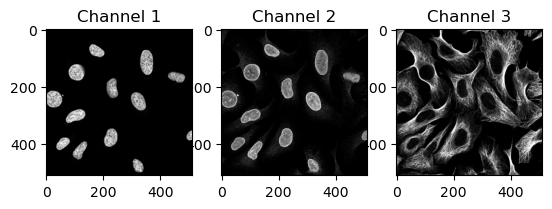

In [4]:
fig, axs = plt.subplots(1, 3)
for i in range(3):
    axs[i].imshow(im[:, :, i], cmap='gray')
    axs[i].set_title(f'Channel {i+1}')

## Segment nuclei using Cellpose

In [5]:
# instantiate a Cellpose model for nuclei

model_nuclei = models.CellposeModel(model_type='nuclei') 

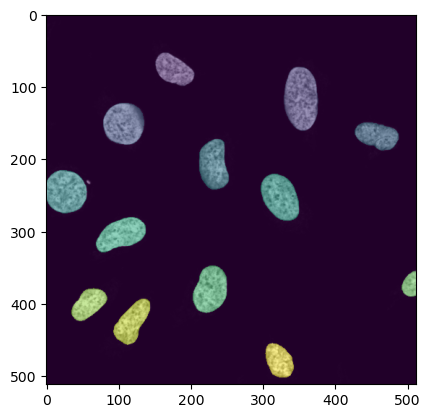

In [12]:
diameter = 50

masks_n, flows, styles = model_nuclei.eval(im[:, :, 0], diameter=diameter)

b_n = segmentation.find_boundaries(masks_n)

plt.figure()
plt.imshow(im[:, :, 0], cmap='gray')
plt.imshow(masks_n, alpha=0.5)
# plt.imshow(b_n, cmap='hot', alpha=0.5 * b_n)

## Segment cells using Cellpose

In [13]:
# instantiate a Cellpose model for cytoplasm

model_cyto = models.CellposeModel(model_type='cyto3') 

In [ ]:
# get help for the eval function

model_cyto.eval?

Signature:
model_cyto.eval(
    x,
    batch_size=8,
    resample=True,
    channels=None,
    channel_axis=None,
    z_axis=None,
    normalize=True,
    invert=False,
    rescale=None,
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    do_3D=False,
    anisotropy=None,
    flow3D_smooth=0,
    stitch_threshold=0.0,
    min_size=15,
    max_size_fraction=0.4,
    niter=None,
    augment=False,
    tile_overlap=0.1,
    bsize=224,
    interp=True,
    compute_masks=True,
    progress=None,
)
Docstring:
segment list of images x, or 4D array - Z x nchan x Y x X

Args:
    x (list, np.ndarry): can be list of 2D/3D/4D images, or array of 2D/3D/4D images
    batch_size (int, optional): number of 224x224 patches to run simultaneously on the GPU
        (can make smaller or bigger depending on GPU memory usage). Defaults to 8.
    resample (bool, optional): run dynamics at original image size (will be slower but create more accurate boundaries). Defaults to True.
    c

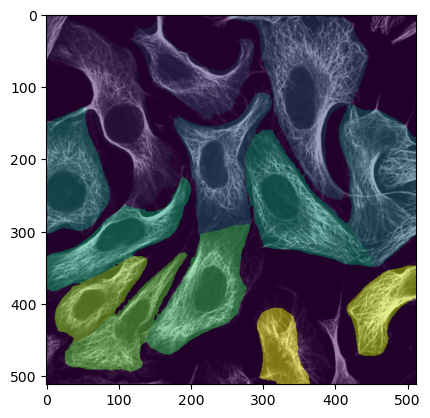

In [ ]:
diameter = 200

masks_c, flows, styles = model_cyto.eval(im[:, :, [0, 2]], diameter=diameter, channels=[2, 1])

# b_c = segmentation.find_boundaries(masks_c)

# plt.figure()
# plt.imshow(im, cmap='gray')
# plt.imshow(b_c, cmap='hot', alpha=0.5 * b_c)

plt.figure()
plt.imshow(im[:, :, 2], cmap='gray')
plt.imshow(masks_c, alpha=0.5)

## Show nuclei and cells together

## Determine cytoplasm

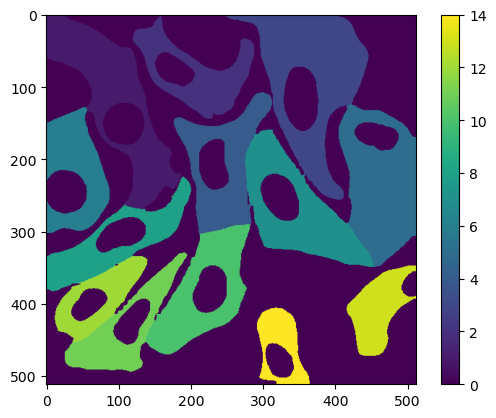

In [ ]:
masks_only_cytoplasm = masks_c * ((masks_c > 0) > (masks_n > 0))

plt.figure()
plt.imshow(masks_only_cytoplasm)
plt.colorbar()

## Extract average intensity in cytoplasm

In [29]:
from skimage.measure import regionprops_table

props = regionprops_table(
    masks_only_cytoplasm,
    intensity_image=im[:, :, 2],
    properties=['label', 'mean_intensity'])

props

{'label': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 'mean_intensity': array([17166.38791162, 17576.87203196, 21547.7094699 , 16505.7453767 ,
        18779.82851098, 17729.14300146, 18278.59079814, 22619.93334081,
         4769.72222222, 22157.82634731, 18855.72565916, 17247.27309714,
        29849.12853551, 19895.55679841])}

In [30]:
print('The mean intensity of Actin in the cytoplasm is:', props['mean_intensity'].mean())

The mean intensity of Actin in the cytoplasm is: 18784.245935808936
